# Semana 4 — Feature engineering y machine learning

**Objetivo.** Tabularizar una serie horaria, construir lags y ventanas sin fuga, y evaluar modelos mediante walk-forward con embargo de 24 horas.

- **Datasets:** `data/04_bike/bike_hour.csv` y `data/04_bike/bike_day.csv`
- **Duración:** 4–5 horas
- **Target:** `cnt`, alquileres por hora/día
- **Seed:** 42

**Contrato de secciones:** Sección 0: Configuración y contrato de datos; Sección 1: Análisis previo; Sección 2: Estrategia de validación; Sección 3: Modelado; Sección 4: Análisis posterior; Sección 5: Lecciones metodológicas; Sección 6: Ejercicios.

**Caso de negocio.** Un operador de bicicletas compartidas debe decidir cada hora cuántas bicicletas reubicar entre estaciones. Anticipar la demanda por hora permite redistribuir la flota antes de que unas estaciones se vacíen y otras se saturen. El costo del error es asimétrico: subestimar deja estaciones sin bicicletas (usuarios que migran a otro medio y pérdida de ingresos), mientras que sobrestimar mueve unidades sin necesidad (combustible, personal y desgaste). Un modelo con features construidas sin información del futuro es la base para automatizar esa decisión.

**Pregunta guía.** ¿Cómo construyo features sin filtrar información del futuro?

> *Nivel de análisis: demanda agregada de alquileres por hora (estación × hora), no comportamiento individual de usuarios. Las conclusiones aplican a decisiones de logística y rebalanceo de flota, no a intervenciones sobre preferencias individuales de transporte.*

### 0.1 Imports y reproducibilidad

Se fijan seeds y se usan modelos CPU reproducibles.

**¿Por qué importa?** La semilla global del notebook (`seed=42`) controla el muestreo, el arranque de los árboles y cualquier paso aleatorio: con el mismo código y los mismos datos se obtienen exactamente los mismos resultados. En producción, la reproducibilidad es un requisito de auditoría: si un resultado cambia sin tocar el código, no se puede atribuir a la operación real.

**Pausa para pensar.** Antes de seguir: ¿qué necesita una persona para reproducir este notebook mañana? Datos, semillas, versiones y orden de celdas — el germen del *checklist de reproducibilidad* de la Sección 5.

In [1]:
# Imports agrupados: base (pathlib, random, time, warnings), datos (numpy, pandas), visualización
# (matplotlib, seaborn), estadística (scipy, statsmodels) y ML (sklearn, lightgbm).
# Reproducibilidad: se fija SEED=42 y se siembran random/numpy antes de cualquier operación aleatoria.
# Modelos CPU: lightgbm y sklearn usan n_jobs (no GPU) para que el notebook corra en cualquier máquina.
from __future__ import annotations
from pathlib import Path
import random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from lightgbm import LGBMRegressor
SEED=42
random.seed(SEED); np.random.seed(SEED)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid",context="notebook")
plt.rcParams["figure.figsize"]=(12,4)

### 0.2 Rutas portables

Se resuelven ambos archivos desde raíz o notebooks.

`resolve()` busca el CSV tanto si el notebook se ejecuta desde `notebooks/` como desde la raíz del curso, y detiene la ejecución con un `assert` si el archivo no existe. Así el mismo cuaderno funciona en cualquier máquina sin editar rutas a mano.

In [2]:
# resolve() busca el archivo relativo a notebooks/ o a la raíz del curso; el assert
# convierte un CSV ausente en un error claro y temprano.
def resolve(relative: str)->Path:
    candidates=[Path(relative),Path("../")/relative]; path=next((p for p in candidates if p.exists()),None); assert path is not None,relative; return path
HOUR_PATH=resolve("data/04_bike/bike_hour.csv"); DAY_PATH=resolve("data/04_bike/bike_day.csv")
print(HOUR_PATH.resolve()); print(DAY_PATH.resolve())

/home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/04_bike/bike_hour.csv
/home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/04_bike/bike_day.csv


### 0.3 Carga

Se validan dimensiones exactas.

Las aserciones convierten el contrato de datos en una barrera ejecutable: si el proveedor cambiara el esquema o el número de filas, el notebook se detiene antes de propagar el error a las secciones siguientes.

In [3]:
# Contrato de datos: 17 379 filas horarias × 17 columnas y 731 filas diarias × 16 columnas.
# Si el proveedor cambia el esquema, la aserción detiene el notebook antes de seguir.
hour_raw=pd.read_csv(HOUR_PATH,parse_dates=["dteday"]); day_raw=pd.read_csv(DAY_PATH,parse_dates=["dteday"])
assert hour_raw.shape==(17_379,17); assert day_raw.shape==(731,16)
print(hour_raw.shape,day_raw.shape)

(17379, 17) (731, 16)


### 0.4 Schema horario

Columnas de calendario, clima y conteos.

El esquema se divide en tres bloques: (1) calendario (`season`, `yr`, `mnth`, `hr`, `weekday`, `workingday`, `holiday`), (2) meteorología (`weathersit`, `temp`, `atemp`, `hum`, `windspeed`) y (3) conteos de demanda (`casual`, `registered`, `cnt`). El bloque (3) es especial: `cnt` es el target y `casual`/`registered` son sus componentes, excluidos de features (ver 0.5).

In [4]:
# hour_raw.info() resume dtypes y nulos por columna; auditoría visual del esquema.
hour_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

### 0.5 Contrato algebraico

`cnt = casual + registered`; esos componentes se excluyen de features para evitar fuga directa.

**Anti-patrón de la semana.** `casual` y `registered` son una descomposición *ex post* del target: conocerlas equivale a conocer la respuesta exacta. Usarlas como features es la fuga más directa posible: el modelo no aprende patrones, lee la solución. Regla operativa: **toda columna que se derive algebraicamente del target queda fuera de `X`**, igual que el propio `cnt`.

In [5]:
# Verificación contable: cnt debe ser exactamente casual + registered (identidad del contrato 0.5).
# Estas dos columnas quedan excluidas de features: son una descomposición ex post del target.
assert np.array_equal(hour_raw.cnt.values,(hour_raw.casual+hour_raw.registered).values)
assert hour_raw.instant.is_unique
print("Identidad cnt verificada")

Identidad cnt verificada


### 0.6 Timestamp horario

Se combina fecha y hora.

El dataset separa la fecha (`dteday`) y la hora (`hr`) en columnas distintas; `ds` las unifica en un único índice temporal que permite alinear lags, ventanas y folds. El `assert` garantiza un índice único y ordenado, prerrequisito de cualquier operación temporal.

In [6]:
# ds = fecha + hora: índice temporal único y monótono, prerrequisito para lags y folds.
hour_raw["ds"]=hour_raw["dteday"]+pd.to_timedelta(hour_raw["hr"],unit="h")
assert hour_raw.ds.is_unique and hour_raw.ds.is_monotonic_increasing
print(hour_raw.ds.min(),hour_raw.ds.max())

2011-01-01 00:00:00 2012-12-31 23:00:00


### 0.7 Nulos y duplicados

Auditoría antes de features.

Un conteo de nulos y duplicados a esta altura es barato y evita sorpresas: los modelos tabulares asumen filas completas, y un duplicado en una serie temporal suele indicar un error de extracción.

In [7]:
# Auditoría rápida: cero nulos y cero duplicados en ambos datasets.
print("Nulos hour/day:",hour_raw.isna().sum().sum(),day_raw.isna().sum().sum()); print("Duplicados:",hour_raw.duplicated().sum(),day_raw.duplicated().sum())

Nulos hour/day: 0 0
Duplicados: 0 0


### 0.8 Gaps horarios

La fuente no tiene todas las horas del calendario.

Comparando con el calendario completo se detectan 165 horas ausentes (en su mayoría en torno a las 03:00, típico de ventanas de mantenimiento). Es un hallazgo de negocio: el operador no registra demanda en esas horas y el modelado debe decidir cómo tratarlas (se eliminan en 2.6).

In [8]:
# Gaps: la fuente omite horas del calendario; se listan las primeras para inspeccionar el patrón.
full_index=pd.date_range(hour_raw.ds.min(),hour_raw.ds.max(),freq="h"); gaps=full_index.difference(hour_raw.ds)
print("Esperadas",len(full_index),"observadas",hour_raw.ds.nunique(),"gaps",len(gaps)); gaps[:10]

Esperadas 17544 observadas 17379 gaps 165


DatetimeIndex(['2011-01-02 05:00:00', '2011-01-03 02:00:00',
               '2011-01-03 03:00:00', '2011-01-04 03:00:00',
               '2011-01-05 03:00:00', '2011-01-06 03:00:00',
               '2011-01-07 03:00:00', '2011-01-11 03:00:00',
               '2011-01-11 04:00:00', '2011-01-12 03:00:00'],
              dtype='datetime64[ns]', freq=None)

### 0.9 Rango target

Perfil descriptivo.

`cnt` va de 1 a 977 alquileres/hora con media 189.5 y mediana 142: la cola derecha (picos de hora punta) eleva la media por encima de la mediana. Esa asimetría anticipa que el error absoluto será mayor en horas punta, lo que confirmaremos en la segmentación pico/valle de la Sección 4.

In [9]:
# Perfil del target: media (189.5) > mediana (142) por la cola derecha de horas punta.
hour_raw.cnt.describe(percentiles=[.01,.25,.5,.75,.95,.99]).to_frame().T

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
cnt,17379.0,189.463088,181.387599,1.0,2.0,40.0,142.0,281.0,563.1,782.22,977.0


### 0.10 Comparación diaria

La suma horaria debe igualar `cnt` diario.

Conciliación contable entre ambos archivos: la suma de las 24 horas de cada día debe coincidir exactamente con el `cnt` diario. La diferencia es 0 en los 731 días, lo que valida que los dos datasets provienen del mismo registro y que la granularidad horaria es consistente.

In [10]:
# Conciliación: la suma horaria por día debe coincidir exactamente con el cnt diario.
daily_from_hour=hour_raw.groupby("dteday").cnt.sum(); alignment=pd.DataFrame({"hour_sum":daily_from_hour,"day_cnt":day_raw.set_index("dteday").cnt}); alignment["difference"]=alignment.hour_sum-alignment.day_cnt; alignment.difference.describe()

count    731.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: difference, dtype: float64

## 1. Análisis previo (pre-modeling)

Se estudian patrones, estacionalidad, estacionariedad, outliers y cambios antes de tabularizar.

Este bloque responde a las preguntas de negocio previas al modelo: ¿cuándo hay demanda? (perfil horario, día de semana, estación), ¿la serie es estable? (estacionariedad) y ¿hay valores anómalos o cambios de régimen? (outliers, CUSUM). Los hallazgos justifican las decisiones de feature engineering de la Sección 2.

### 1.1 Serie horaria

La trayectoria completa muestra crecimiento y ciclos.

Se observan tres hechos estilizados: (1) crecimiento de 2011 a 2012, (2) estacionalidad anual con verano más activo y (3) estacionalidad intradiaria con picos de desplazamiento. Estos patrones justifican lags de 24 y 168 horas (ciclo diario y semanal) y la interacción de hora con día laboral.

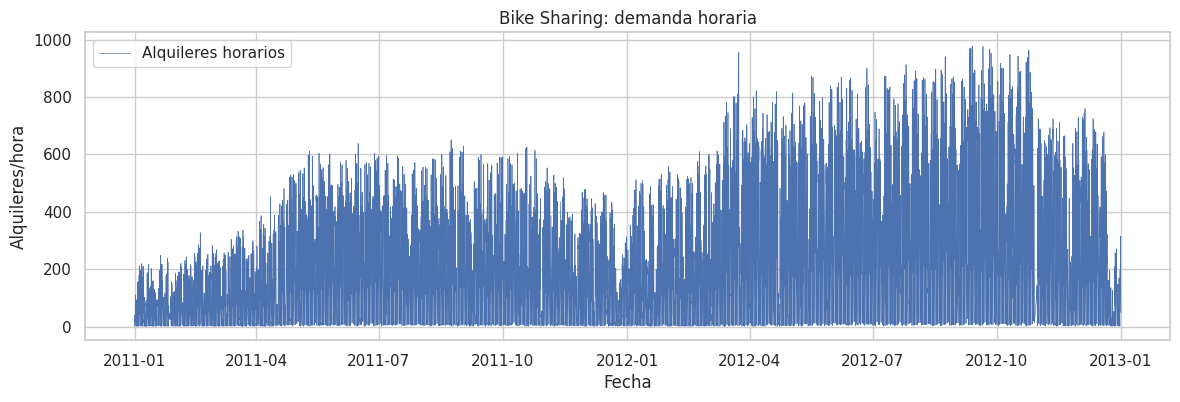

In [11]:
# Serie completa: crecimiento anual, estacionalidad anual e intradiaria; lw=.5 evita saturar el gráfico.
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(hour_raw.ds,hour_raw.cnt,lw=.5,label="Alquileres horarios"); ax.set(title="Bike Sharing: demanda horaria",xlabel="Fecha",ylabel="Alquileres/hora"); ax.legend(); plt.show()

### 1.2 Zoom de dos semanas

Patrón intradiario.

En catorce días consecutivos se repite la estructura de dos picos diarios (mañana y tarde) con valles nocturnos. La repetición del patrón sugiere que los lags de 24 horas capturarán gran parte de la inercia de la demanda.

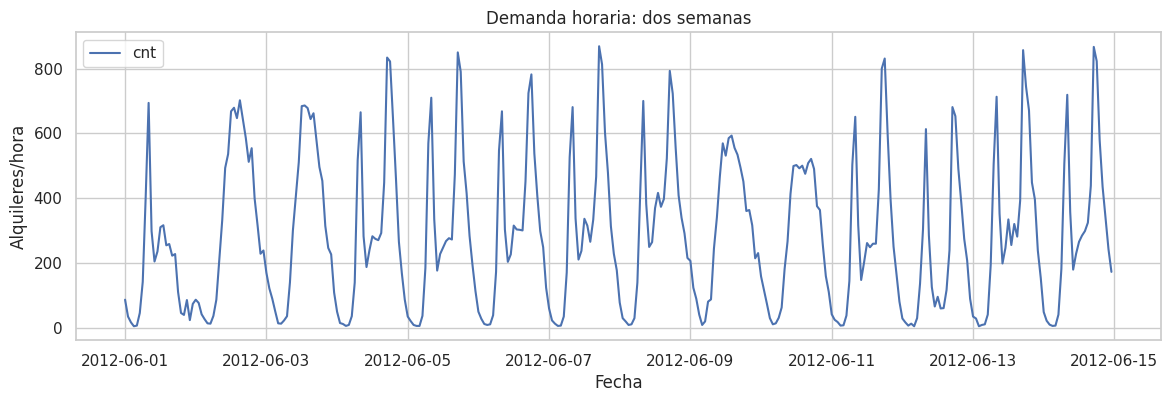

In [12]:
# Zoom de 14 días para ver el patrón intradiario (picos de mañana y tarde).
z=hour_raw.set_index("ds").loc["2012-06-01":"2012-06-14","cnt"]; fig,ax=plt.subplots(figsize=(14,4)); ax.plot(z.index,z,label="cnt"); ax.set(title="Demanda horaria: dos semanas",xlabel="Fecha",ylabel="Alquileres/hora"); ax.legend(); plt.show()

### 1.3 Perfil por hora

Media y mediana.

La demanda horaria es bimodal: pico matutino hacia las 8 h y pico vespertino hacia las 17-18 h, con mínimos de madrugada. La brecha entre media y mediana crece en horas punta, donde algunos días extremos elevan la media.

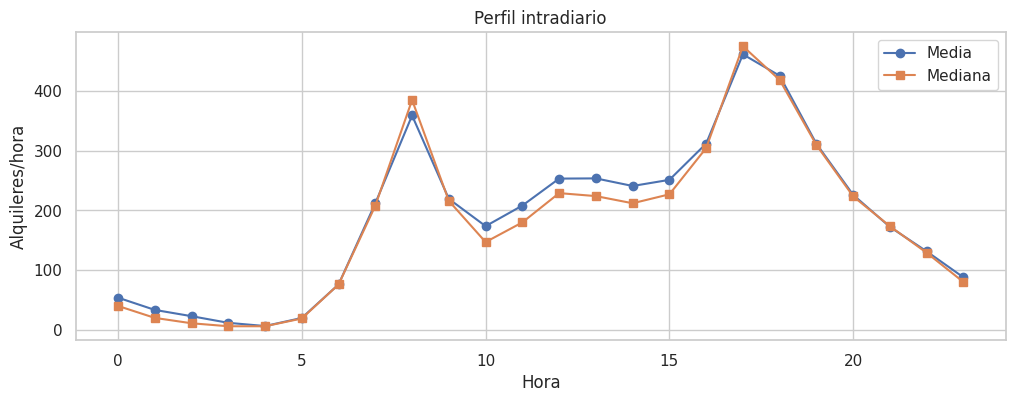

In [13]:
# Perfil horario: media vs mediana; bimodalidad de la demanda (desplazamientos).
p=hour_raw.groupby("hr").cnt.agg(["mean","median"]); fig,ax=plt.subplots(); ax.plot(p.index,p["mean"],marker="o",label="Media"); ax.plot(p.index,p["median"],marker="s",label="Mediana"); ax.set(title="Perfil intradiario",xlabel="Hora",ylabel="Alquileres/hora"); ax.legend(); plt.show()

### 1.4 Laboral vs no laboral

La interacción con hora es importante.

En días laborables la demanda se concentra en los desplazamientos casa-trabajo; en no laborables el perfil es más plano y se desplaza hacia el mediodía. Esta diferencia motiva el uso de `workingday` como feature y las interacciones horarias del pipeline.

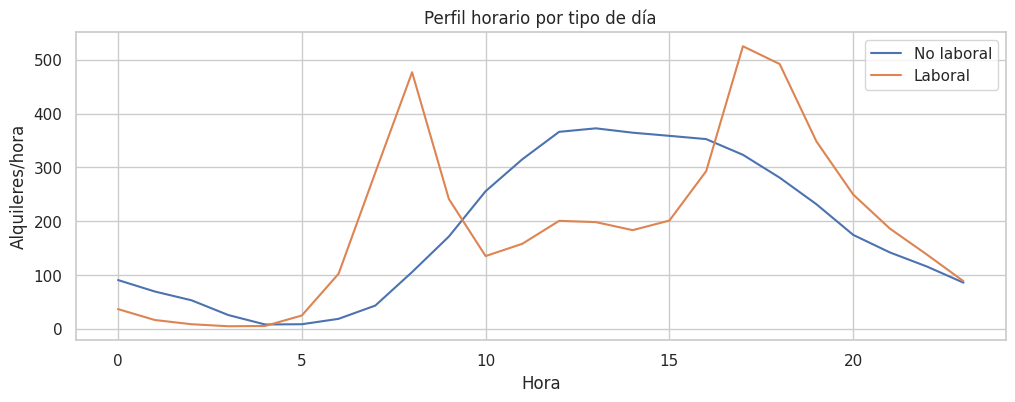

In [14]:
# Interacción hora × laboral: perfiles distintos, base para features de interacción.
p=hour_raw.pivot_table(index="hr",columns="workingday",values="cnt",aggfunc="mean"); fig,ax=plt.subplots(); ax.plot(p.index,p[0],label="No laboral"); ax.plot(p.index,p[1],label="Laboral"); ax.set(title="Perfil horario por tipo de día",xlabel="Hora",ylabel="Alquileres/hora"); ax.legend(); plt.show()

### 1.5 Día de semana

Distribución robusta.

El boxplot (sin outliers) muestra menor demanda el fin de semana y un patrón estable entre lunes y viernes. Nota: la fuente codifica `weekday` con 0 = domingo, convención que conviene recordar al interpretar tablas posteriores.

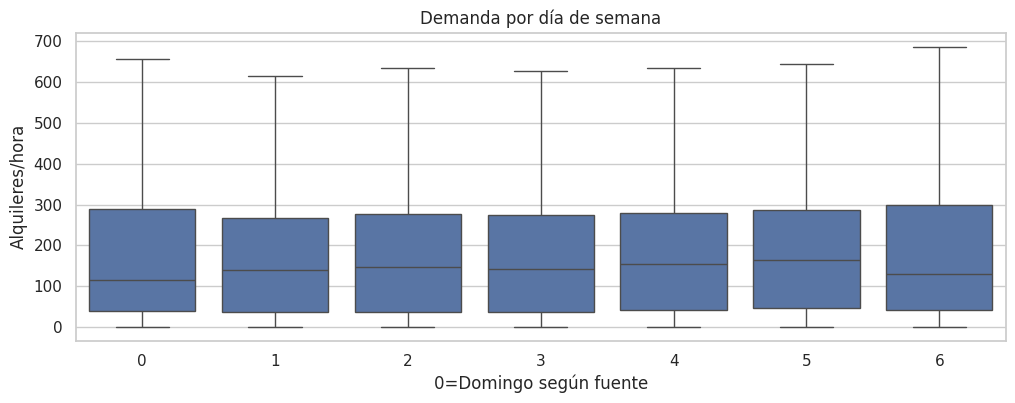

In [15]:
# Boxplot por día de semana; showfliers=False mantiene la lectura de la distribución central.
fig,ax=plt.subplots(); sns.boxplot(data=hour_raw,x="weekday",y="cnt",showfliers=False,ax=ax); ax.set(title="Demanda por día de semana",xlabel="0=Domingo según fuente",ylabel="Alquileres/hora"); plt.show()

### 1.6 Estación

`season` es categórica.

La demanda crece de invierno (1) a verano (3) y cae en otoño (4). Aunque la codificación es numérica (1-4), no hay relación lineal: debe tratarse como variable categórica, como hace LightGBM al recibirla sin estandarizar.

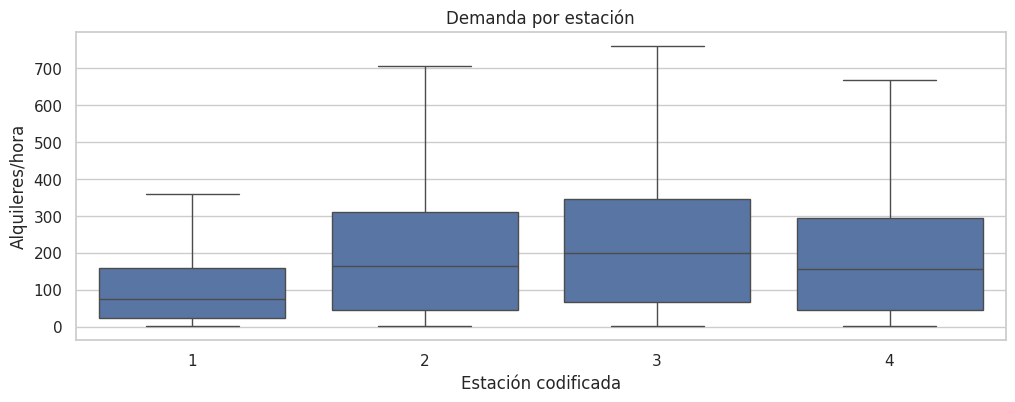

In [16]:
# season es categórica (1-4), no ordinal: el boxplot muestra demanda creciente hacia verano.
fig,ax=plt.subplots(); sns.boxplot(data=hour_raw,x="season",y="cnt",showfliers=False,ax=ax); ax.set(title="Demanda por estación",xlabel="Estación codificada",ylabel="Alquileres/hora"); plt.show()

### 1.7 Clima

Relación descriptiva temperatura-demanda.

Con una muestra aleatoria fijada por `seed` se aprecia una relación creciente entre temperatura normalizada y demanda, modulada por la estación. Es una correlación descriptiva: la causalidad requiere validación con el modelo, y la temperatura debe usarse solo con valores disponibles al predecir.

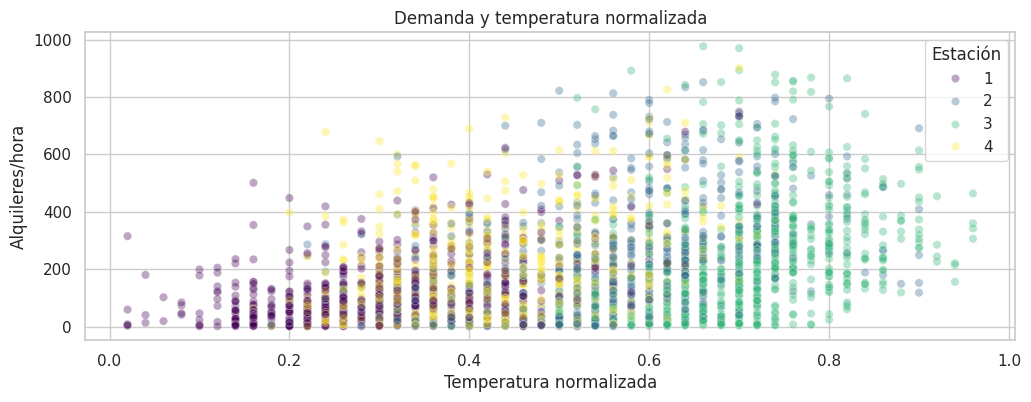

In [17]:
# Muestra aleatoria fija con random_state=SEED: el gráfico es reproducible.
# Relación descriptiva temperatura-demanda, modulada por estación.
fig,ax=plt.subplots(); sns.scatterplot(data=hour_raw.sample(3000,random_state=SEED),x="temp",y="cnt",hue="season",alpha=.35,palette="viridis",ax=ax); ax.set(title="Demanda y temperatura normalizada",xlabel="Temperatura normalizada",ylabel="Alquileres/hora"); ax.legend(title="Estación"); plt.show()

### 1.8 Humedad y viento

Hexbin reduce overplotting.

La humedad alta y el viento fuerte tienden a reducir la demanda (viajar en bici es menos atractivo), pero la relación es difusa. Estas variables entran como covariables; el hexbin evita que más de 17 000 puntos oculten la densidad real.

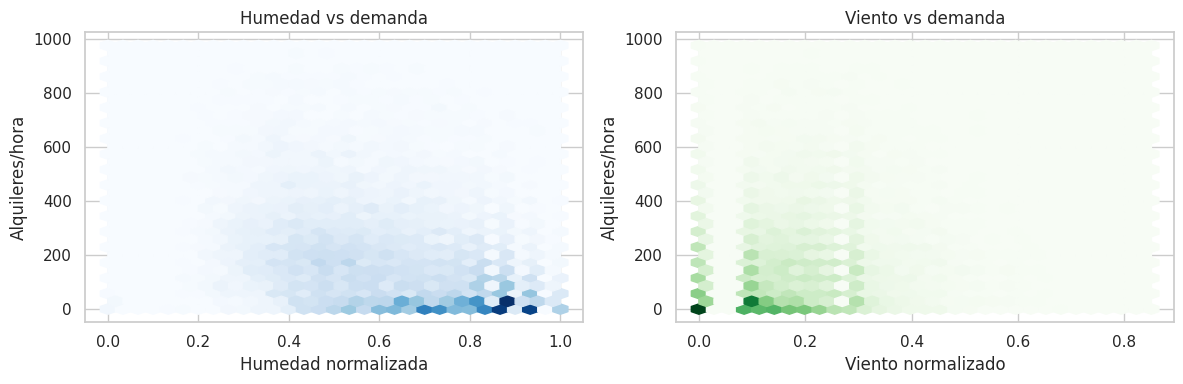

In [18]:
# Hexbin: evita overplotting con 17 000 puntos; humedad alta y viento reducen demanda.
fig,axes=plt.subplots(1,2,figsize=(12,4)); axes[0].hexbin(hour_raw.hum,hour_raw.cnt,gridsize=30,cmap="Blues"); axes[0].set(title="Humedad vs demanda",xlabel="Humedad normalizada",ylabel="Alquileres/hora"); axes[1].hexbin(hour_raw.windspeed,hour_raw.cnt,gridsize=30,cmap="Greens"); axes[1].set(title="Viento vs demanda",xlabel="Viento normalizado",ylabel="Alquileres/hora"); plt.tight_layout(); plt.show()

### 1.9 Serie regular EDA

Se reindexa; target se interpola solo para STL/ACF.

Los métodos espectrales y de autocorrelación requieren un índice regular. La interpolación es una decisión deliberada y acotada: solo alimenta el análisis exploratorio (STL, ACF y tests); el modelado usa el dataset con gaps eliminados (2.6) sin interpolar el target.

In [19]:
# Reindexación al calendario completo; interpolación SOLO para EDA (STL/ACF), no para modelado.
regular=hour_raw.set_index("ds").reindex(full_index); regular.index.name="ds"; y_eda=regular.cnt.interpolate("time").ffill().bfill(); print(y_eda.isna().sum())

0


### 1.10 STL diaria

Periodo 24.

STL descompone la serie de 2012 en tendencia, estacionalidad diaria (periodo 24) y residuo, con descomposición robusta para resistir outliers. La estacionalidad resultante confirma el ciclo intradiario; el residuo se reutiliza en el análisis de outliers (1.15).

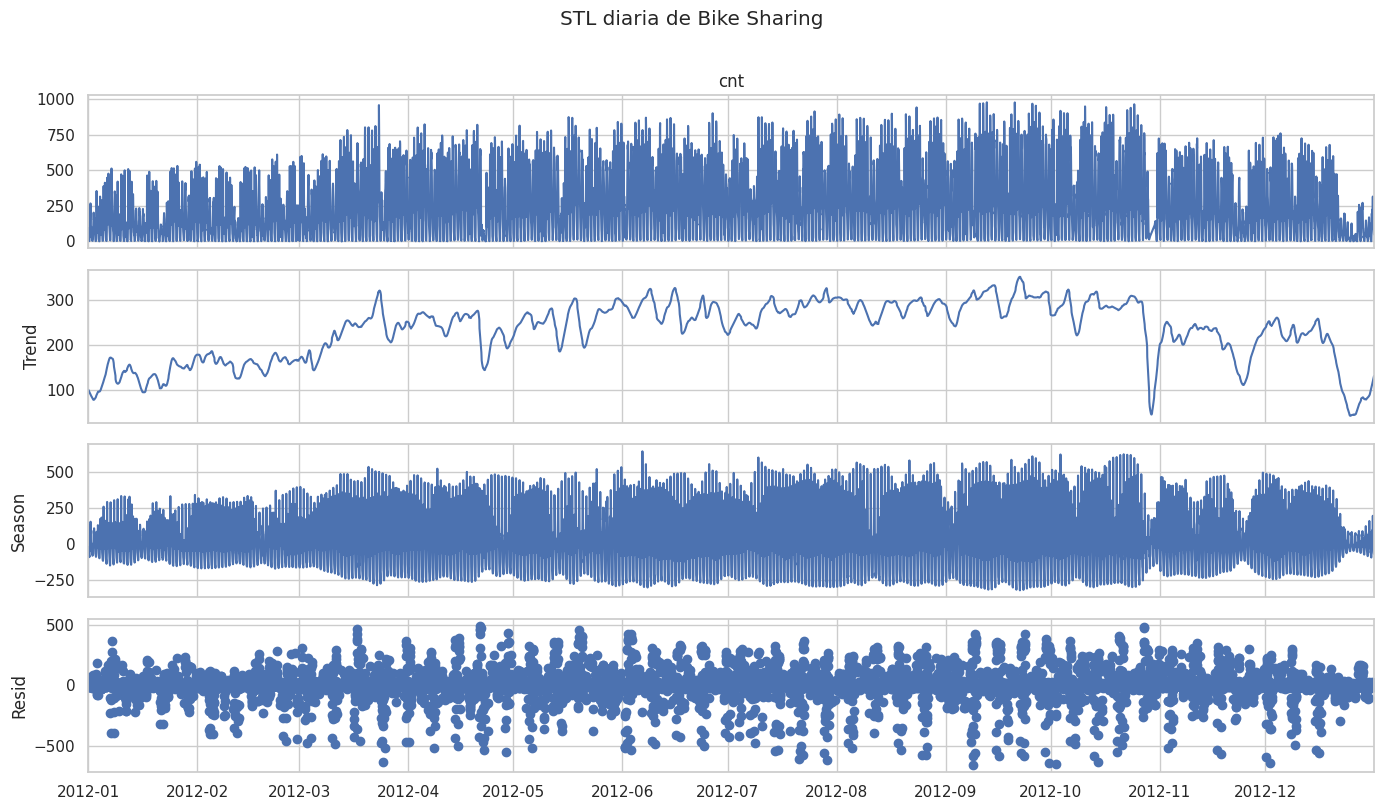

In [20]:
# STL robusta con periodo 24 sobre 2012: tendencia, estacionalidad diaria y residuo.
stl=STL(y_eda.loc["2012-01-01":"2012-12-31"],period=24,robust=True).fit(); fig=stl.plot(); fig.set_size_inches(14,8); fig.suptitle("STL diaria de Bike Sharing",y=1.01); plt.tight_layout(); plt.show()

### 1.11 Estacionariedad

**ADF H₀:** raíz unitaria. **KPSS H₀:** estacionariedad. α=0.05.

Los dos tests son complementarios: ADF rechaza raíz unitaria (evidencia de estacionariedad) y KPSS rechaza estacionariedad (evidencia de no estacionariedad). Cuando ambos rechazan, la serie no es estacionaria en sentido estricto, típico de series con tendencia y estacionalidad fuertes como la demanda horaria.

### 1.12 Tests

Se reportan hipótesis, estadístico y decisión.

La función `stationarity_report` unifica ADF y KPSS en una tabla con hipótesis nula, estadístico, p-valor y decisión al 5 %. Reportar la hipótesis junto a la decisión evita el error clásico de leer solo el p-valor sin recordar qué prueba cada test.

In [21]:
# Reporte unificado ADF/KPSS: hipótesis nula, estadístico, p-valor y decisión a nivel alpha.
# ADF H0: raíz unitaria; KPSS H0: estacionariedad. Tests complementarios.
def stationarity_report(x: pd.Series,label: str,alpha: float=.05)->pd.DataFrame:
    x=x.dropna(); a=adfuller(x,autolag="AIC"); k=kpss(x,regression="c",nlags="auto"); return pd.DataFrame([{"test":"ADF","serie":label,"H0":"raíz unitaria","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<alpha else "no rechazar H0"},{"test":"KPSS","serie":label,"H0":"estacionaria","stat":k[0],"p_value":k[1],"decision":"rechazar H0" if k[1]<alpha else "no rechazar H0"}])
stationarity_report(y_eda,"nivel")

,test,serie,H0,stat,p_value,decision
0,ADF,nivel,raíz unitaria,-6.944056,1.007794e-09,rechazar H0
1,KPSS,nivel,estacionaria,19.405038,1.000000e-02,rechazar H0


### 1.13 Diferencia diaria

Test sobre yₜ−yₜ₋₂₄.

Al restar el valor de hace 24 horas se elimina la estacionalidad diaria y la serie residual se comporta como estacionaria (ADF rechaza, KPSS no rechaza). Es la justificación estadística de por qué los lags y ventanas de 24 horas son las unidades naturales de este problema.

In [22]:
# Diferencia diaria y_{t} - y_{t-24}: elimina la estacionalidad de 24 horas.
d24=y_eda.diff(24).dropna(); stationarity_report(d24,"diferencia diaria")

,test,serie,H0,stat,p_value,decision
0,ADF,diferencia diaria,raíz unitaria,-22.530182,0.0,rechazar H0
1,KPSS,diferencia diaria,estacionaria,0.013861,0.1,no rechazar H0


### 1.14 ACF/PACF

Dependencias a 24/168 motivan lags.

La ACF de la diferencia diaria muestra correlaciones significativas en los múltiplos de 24 horas, y la PACF concentra la estructura en los primeros lags. Estas figuras son la evidencia empírica de la elección `LAGS=[1,2,3,6,12,24,48,168]`: cubren el corto plazo, el ciclo diario y el semanal.

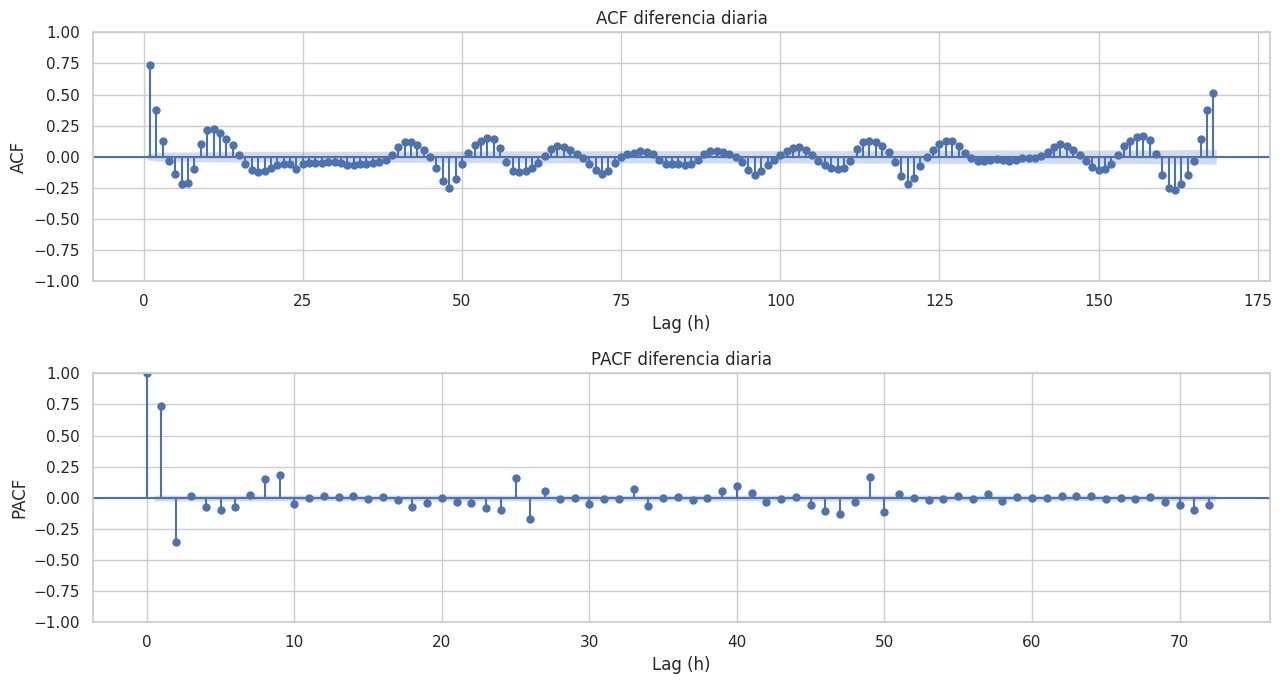

In [23]:
# ACF hasta 168 h y PACF hasta 72 h sobre la diferencia diaria: dependencias en 24/48/168.
fig,axes=plt.subplots(2,1,figsize=(13,7)); plot_acf(d24.tail(6000),lags=168,zero=False,ax=axes[0]); plot_pacf(d24.tail(6000),lags=72,method="ywm",ax=axes[1]); axes[0].set(title="ACF diferencia diaria",xlabel="Lag (h)",ylabel="ACF"); axes[1].set(title="PACF diferencia diaria",xlabel="Lag (h)",ylabel="PACF"); plt.tight_layout(); plt.show()

### 1.15 Outliers

MAD en residuos STL.

Se marcan como candidatos los residuos STL cuya desviación mediana absoluta (MAD) supera 4.5 veces la dispersión robusta; hay 1887 candidatos en 2012. La cifra es alta porque la demanda horaria es intrínsecamente ruidosa: más que error de datos, señala eventos atípicos (clima extremo, eventos).

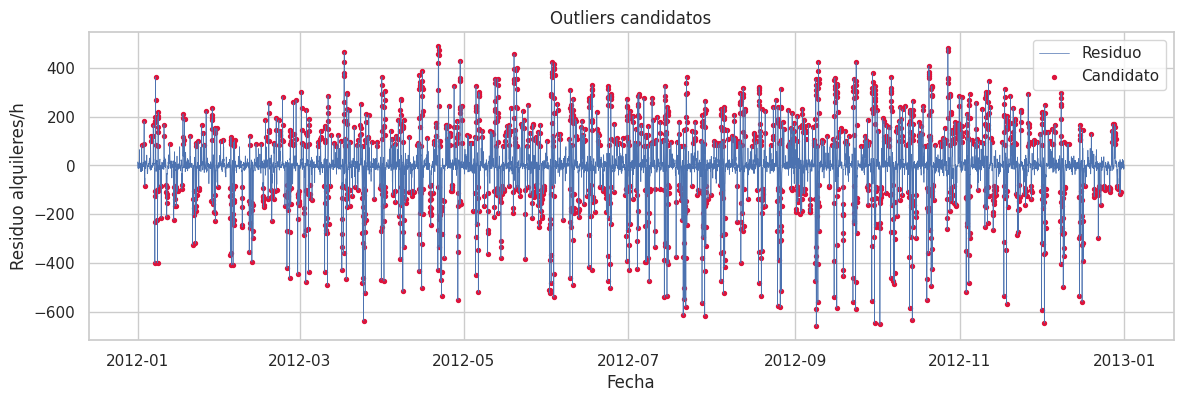

1887


In [24]:
# Outliers robustos sobre residuos STL: |z| MAD > 4.5; 1887 candidatos en 2012.
med=np.median(stl.resid); mad=np.median(np.abs(stl.resid-med)); rz=.6745*(stl.resid-med)/mad; out=stl.resid[np.abs(rz)>4.5]; fig,ax=plt.subplots(figsize=(14,4)); ax.plot(stl.resid.index,stl.resid,lw=.5,label="Residuo"); ax.scatter(out.index,out,s=8,color="crimson",label="Candidato"); ax.set(title="Outliers candidatos",xlabel="Fecha",ylabel="Residuo alquileres/h"); ax.legend(); plt.show(); print(len(out))

### 1.16 CUSUM

Cambio estructural descriptivo.

La suma acumulada de residuos estandarizados detecta desviaciones sostenidas del nivel medio; el máximo absoluto en 2012-03-31 09:00 sugiere un episodio de cambio. En este notebook el CUSUM es descriptivo: alerta de regímenes distintos y refuerza evaluar con walk-forward en lugar de un único split aleatorio.

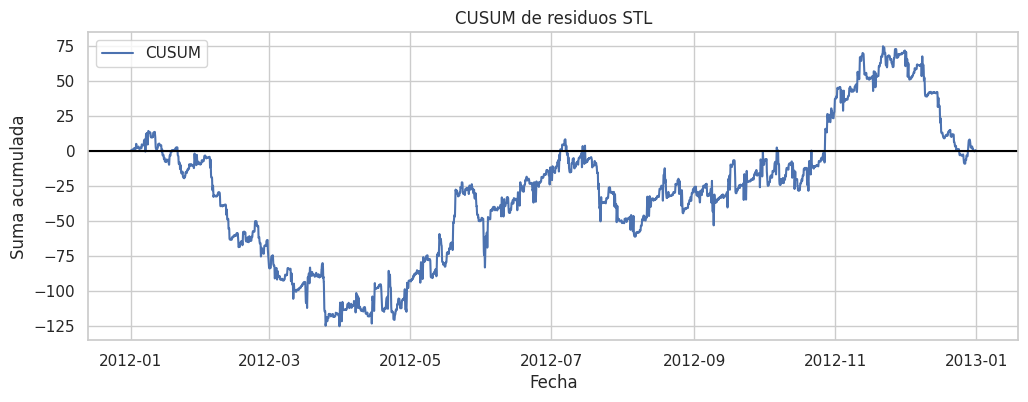

2012-03-31 09:00:00


In [25]:
# CUSUM de residuos estandarizados: máximo absoluto marca el cambio estructural más fuerte.
z=(stl.resid-stl.resid.mean())/stl.resid.std(); cs=z.cumsum(); fig,ax=plt.subplots(); ax.plot(cs.index,cs,label="CUSUM"); ax.axhline(0,color="black"); ax.set(title="CUSUM de residuos STL",xlabel="Fecha",ylabel="Suma acumulada"); ax.legend(); plt.show(); print(cs.abs().idxmax())

## 2. Estrategia de validación

**Walk-forward con embargo de 24 horas.** Tres folds usan train expansivo, un embargo diario y test de siete días. El embargo evita que ventanas/targets cercanos a la frontera compartan información del mismo ciclo diario.

**¿Por qué walk-forward y no un split aleatorio?** En series temporales las filas no son intercambiables: un split aleatorio mezclaría 2011 y 2012 y el modelo "vería" el futuro en el train. El walk-forward entrena solo con el pasado y evalúa ventanas futuras, replicando el uso operativo: cada mañana se reentrena con todo lo conocido y se pronostica la semana siguiente.

**¿Por qué un embargo?** Aunque train y test sean contiguos, una feature calculada cerca de la frontera podría incorporar observaciones del periodo de test. El embargo de 24 horas descarta esas observaciones limítrofes y se alinea con el ciclo diario del negocio (redistribución por día).

### 2.1 Feature engineering seguro

Todos los rolling usan `shift(1)`; nunca incluyen yₜ.

La regla de oro: **primero se desplaza el target una posición y luego se agrega**. `x.cnt.shift(1).rolling(w)` promedia las observaciones `t-1, …, t-w`, todas anteriores a `t`; `x.cnt.rolling(w)` sin `shift` incluiría el propio `yₜ` (fuga contemporánea). La misma lógica aplica a los lags: `lag_k = cnt.shift(k)`.

In [26]:
# LAGS: corto plazo (1-12), ciclo diario (24, 48) y semanal (168).
# WINDOWS: agregaciones de 24/48/168 horas sobre cnt.shift(1): nunca incluyen y_t.
# Codificación cíclica sin/cos para hora, día de semana y mes: evita la discontinuidad 23->0.
# Interacciones de negocio: temperatura×hora y festivo×estación.
# Se eliminan dteday, casual y registered antes de tabularizar (anti-patrón de la semana).
LAGS=[1,2,3,6,12,24,48,168]; WINDOWS=[24,48,168]
def make_features(df: pd.DataFrame)->pd.DataFrame:
    x=df.copy().set_index("ds").reindex(full_index); x.index.name="ds"
    for lag in LAGS: x[f"lag_{lag}"]=x.cnt.shift(lag)
    past=x.cnt.shift(1)
    for w in WINDOWS:
        roll=past.rolling(w,min_periods=w); x[f"roll_mean_{w}"]=roll.mean(); x[f"roll_std_{w}"]=roll.std(); x[f"roll_min_{w}"]=roll.min(); x[f"roll_max_{w}"]=roll.max()
    hour=x.index.hour; dow=x.index.dayofweek; month=x.index.month
    x["hour_sin"]=np.sin(2*np.pi*hour/24); x["hour_cos"]=np.cos(2*np.pi*hour/24); x["dow_sin"]=np.sin(2*np.pi*dow/7); x["dow_cos"]=np.cos(2*np.pi*dow/7); x["month_sin"]=np.sin(2*np.pi*month/12); x["month_cos"]=np.cos(2*np.pi*month/12)
    x["temp_x_hour"]=x.temp*hour; x["holiday_x_season"]=x.holiday*x.season
    return x
features=make_features(hour_raw.drop(columns=["dteday","casual","registered"])); print(features.shape)

(17544, 42)


### 2.2 Lista de features

Se excluyen target, identificador y componentes del target.

`DROP` retira `cnt` (target), `instant` (identificador de fila), `yr` (año, correlacionado con la tendencia), y `mnth`/`hr` (redundantes con las codificaciones cíclicas sin/cos). Resultado: 37 features con las que se entrena cada modelo.

In [27]:
# DROP: target (cnt), identificador (instant), año (yr) y codificaciones redundantes (mnth, hr).
# FEATURES: 37 columnas usadas por los modelos.
DROP=["cnt","instant","yr","mnth","hr"]
FEATURES=[x for x in features.columns if x not in DROP]
print(len(FEATURES),FEATURES)

37 ['season', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168', 'roll_mean_24', 'roll_std_24', 'roll_min_24', 'roll_max_24', 'roll_mean_48', 'roll_std_48', 'roll_min_48', 'roll_max_48', 'roll_mean_168', 'roll_std_168', 'roll_min_168', 'roll_max_168', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'temp_x_hour', 'holiday_x_season']


### 2.3 Demostración de leakage

Una media móvil centrada usa valores futuros. Se compara con `shift(1).rolling(24)`, disponible al origen.

**Experimento didáctico.** Se construyen dos versiones de la media móvil de 24 horas: (1) *centrada* (`center=True`), que en cada instante promedia un entorno con horas posteriores, y (2) *pasada segura* (`shift(1).rolling(24)`), que solo usa el pasado. **Pausa para pensar:** antes de ejecutar la siguiente celda, formula tu hipótesis sobre cuál correlacionará más con el target y por qué; compara tu predicción con el resultado de 2.4.

### 2.4 Feature filtrada vs segura

La correlación inflada no es evidencia de utilidad válida.

**Conclusión explícita del experimento.** En los outputs del notebook, la rolling centrada correlaciona 0.400 con el target, frente a 0.362 de la rolling pasada segura. La ventana centrada "parece" más informativa, pero esa ganancia es ficticia: usa información que no existiría al momento de pronosticar. Un modelo entrenado con esa feature reportaría un rendimiento optimista e irreproducible en producción. La lección operativa: **una correlación alta no valida una feature; solo la valida que no filtre el futuro**.

**Lección transferible:** cualquier feature cuya correlación "mejore" al agregar información futura es, por definición, una señal de fuga, no de calidad — la pregunta a hacerse siempre es *¿esta feature existiría en el momento real de pronosticar?*, no *¿cuánto correlaciona?*

In [28]:
# Experimento didáctico: rolling centrada (usa futuro) vs rolling pasada con shift(1).
# La correlación más alta de la versión centrada es un artefacto de fuga, no utilidad real.
leak=features.cnt.rolling(24,center=True,min_periods=24).mean(); safe=features.cnt.shift(1).rolling(24,min_periods=24).mean(); comp=pd.DataFrame({"corr_with_target":[features.cnt.corr(leak),features.cnt.corr(safe)]},index=["centered_leaky","past_only_safe"]); comp

,corr_with_target
centered_leaky,0.400398
past_only_safe,0.362231


### 2.5 Visualización del futuro filtrado

La ventana centrada incorpora hasta 12 horas posteriores.

En el zoom de cuatro días se aprecia que la curva centrada se adelanta al target (suaviza con valores futuros), mientras que la pasada va retrasada de forma natural. La primera nunca podría haberse calculado a las 00:00 del día en curso; la segunda sí.

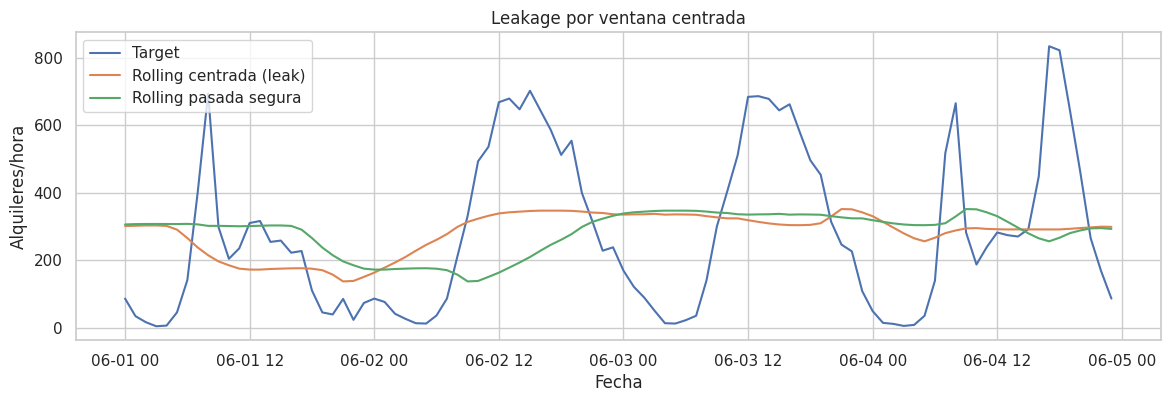

In [29]:
# Zoom temporal: la curva centrada se adelanta al target; la pasada va retrasada de forma natural.
z=slice("2012-06-01","2012-06-04"); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(features.loc[z].index,features.loc[z,"cnt"],label="Target"); ax.plot(leak.loc[z].index,leak.loc[z],label="Rolling centrada (leak)"); ax.plot(safe.loc[z].index,safe.loc[z],label="Rolling pasada segura"); ax.set(title="Leakage por ventana centrada",xlabel="Fecha",ylabel="Alquileres/hora"); ax.legend(); plt.show()

### 2.6 Dataset modelable

Se eliminan gaps y filas sin historia de 168 h.

Se descartan las filas con huecos y las primeras 168 horas sin historia completa de lags. Quedan 11 840 filas (de 17 544 del calendario) entre 2011-04-04 y 2012-12-24. Perder el arranque del histórico es el costo aceptable de exigir un lag semanal completo.

In [30]:
# Filas modelables: sin gaps y con 168 h de historia; 11 840 filas entre 2011-04-04 y 2012-12-24.
model_df=features.dropna(subset=["cnt",*FEATURES]).copy(); print(model_df.shape,model_df.index.min(),model_df.index.max())

(11840, 42) 2011-04-04 05:00:00 2012-12-24 03:00:00


In [31]:
# Checkpoint anti-leakage: convertimos el checklist metodológico en invariantes ejecutables.
# (1) El target es exactamente casual + registered; esas columnas no pueden ser features.
assert np.array_equal(hour_raw.cnt.values, (hour_raw.casual + hour_raw.registered).values)
assert "casual" not in FEATURES and "registered" not in FEATURES, "componentes del target fuera de X"
assert "cnt" not in FEATURES, "el target no puede estar en X"
# (2) Los lags están realmente desplazados: lag_k en t es el valor de t-k horas.
t = 1000  # fila arbitraria de model_df con historia completa (sin NaN)
ts = model_df.index[t]
assert model_df.loc[ts, "lag_1"] == features.loc[ts - pd.Timedelta(hours=1), "cnt"]
assert model_df.loc[ts, "lag_24"] == features.loc[ts - pd.Timedelta(hours=24), "cnt"]
# (3) La rolling "segura" promedia solo el pasado estricto [t-24, t-1] (shift(1) primero).
safe_m = model_df.cnt.shift(1).rolling(24, min_periods=24).mean()
assert np.isclose(safe_m.iloc[t], model_df.cnt.iloc[t - 24:t].mean())
# (4) La rolling centrada incluye el presente y el futuro [t-12, t+11]: fuga demostrable.
leak_m = model_df.cnt.rolling(24, center=True, min_periods=24).mean()
assert np.isclose(leak_m.iloc[t], model_df.cnt.iloc[t - 12:t + 12].mean())
assert not np.isclose(leak_m.iloc[t], safe_m.iloc[t])
# (5) Artefacto empírico: la versión centrada correlaciona más con el target (0.400 vs 0.362).
assert leak.corr(features.cnt) > safe.corr(features.cnt)
print("Checkpoint anti-leakage superado: las features usan solo información del pasado.")

Checkpoint anti-leakage superado: las features usan solo información del pasado.


### 2.7 Folds walk-forward

Test 168 h, embargo 24 h, orígenes separados 30 días.

Los tres orígenes se sitúan al final de la serie, separados 30 días, con test de 168 horas (una semana) y embargo de 24 horas. En la tabla de outputs, el primer fold entrena hasta la fila 10 208 y evalúa de 10 232 a 10 400; el último fold evalúa hasta el final (11 840). El train es expansivo: cada fold acumula todo el pasado anterior.

In [32]:
# Geometría de folds: test de 168 h, embargo de 24 h, orígenes separados 720 h (30 días).
# train_end = origen - embargo: el modelo nunca ve las 24 h previas al test.
H=168; EMBARGO=24; origins=[len(model_df)-H-24*60,len(model_df)-H-24*30,len(model_df)-H]; folds=[]
for i,o in enumerate(origins,1): folds.append({"fold":i,"train_end":o-EMBARGO,"embargo_start":o-EMBARGO,"test_start":o,"test_end":o+H})
pd.DataFrame(folds)

,fold,train_end,embargo_start,test_start,test_end
0,1,10208,10208,10232,10400
1,2,10928,10928,10952,11120
2,3,11648,11648,11672,11840


In [33]:
# Función reutilizable: walk-forward con embargo (documentación ejecutable).
# El embargo de 24 h separa train y test para que ninguna ventana del test se
# contamine con información del mismo ciclo diario que el train.
def build_walk_forward_folds(n_rows: int, test_h: int = 168, embargo_h: int = 24, spacing_h: int = 720, n_folds: int = 3) -> list[dict]:
    """Genera n_folds con train expansivo, embargo temporal y test de test_h horas."""
    origins = [n_rows - test_h - spacing_h * i for i in range(n_folds - 1, -1, -1)]
    folds = []
    for i, o in enumerate(origins, 1):
        folds.append({"fold": i, "train_end": o - embargo_h, "embargo_start": o - embargo_h, "test_start": o, "test_end": o + test_h})
    return folds

# Verificamos que reproduce exactamente los folds de la Sección 2 (reproducibilidad).
rebuilt = build_walk_forward_folds(len(model_df))
assert [f["test_start"] for f in rebuilt] == [f["test_start"] for f in folds]
assert [f["train_end"] for f in rebuilt] == [f["train_end"] for f in folds]
print("Walk-forward con embargo reproducible:", rebuilt)

Walk-forward con embargo reproducible: [{'fold': 1, 'train_end': 10208, 'embargo_start': 10208, 'test_start': 10232, 'test_end': 10400}, {'fold': 2, 'train_end': 10928, 'embargo_start': 10928, 'test_start': 10952, 'test_end': 11120}, {'fold': 3, 'train_end': 11648, 'embargo_start': 11648, 'test_start': 11672, 'test_end': 11840}]


### 2.8 Diagrama

Embargo rojo entre train y test.

El gráfico resume la geometría de la validación: cada barra gris es el train expansivo, el segmento rojo es el embargo de 24 horas que se descarta y el negro es el test de 168 horas. Conviene guardar esta imagen mental: cualquier pipeline que no respete esta estructura (por ejemplo, escalando con el test) está filtrando información.

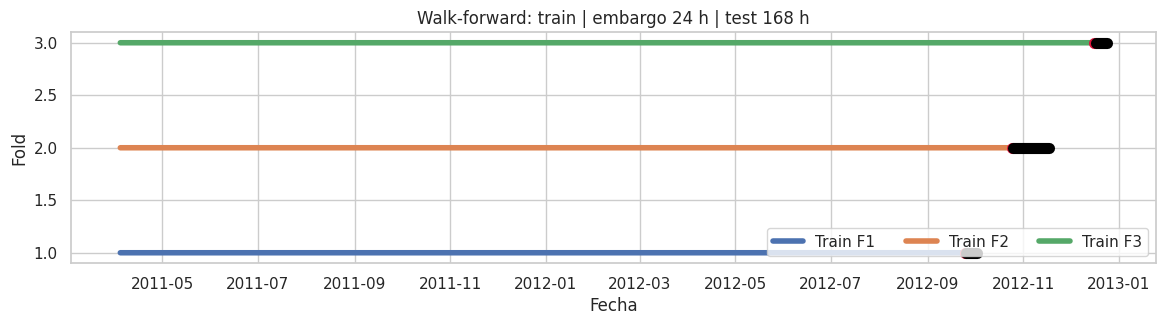

In [34]:
# Diagrama train | embargo (rojo) | test (negro): verificación visual de la estructura walk-forward.
fig,ax=plt.subplots(figsize=(14,3));
for f in folds:
    ax.plot(model_df.index[:f["train_end"]],[f["fold"]]*f["train_end"],lw=4,label=f"Train F{f['fold']}"); ax.plot(model_df.index[f["embargo_start"]:f["test_start"]],[f["fold"]]*EMBARGO,lw=8,color="crimson"); ax.plot(model_df.index[f["test_start"]:f["test_end"]],[f["fold"]]*H,lw=8,color="black")
ax.set(title="Walk-forward: train | embargo 24 h | test 168 h",xlabel="Fecha",ylabel="Fold"); ax.legend(ncol=3); plt.show()

## 3. Modelado

> **Methodology Card — Checklist anti-leakage**  
> 1) lags con shift; 2) rolling sobre pasado; 3) scaler solo train; 4) embargo ≥ dependencia operacional; 5) excluir componentes del target; 6) covariables futuras realmente disponibles; 7) test nunca participa en selección.

Los puntos 1, 2 y 5 ya están implementados y verificados en la Sección 2; la celda *Checkpoint anti-leakage* (tras 2.6) los convierte en aserciones ejecutables. Los puntos 3, 4, 6 y 7 se respetan en el bucle de walk-forward: cada modelo se ajusta solo con train, el embargo separa los bloques, las covariables (clima, calendario) son conocidas al pronosticar y el test nunca interviene en la selección.

### 3.1 Métricas

$$MAE=n^{-1}\sum|e_t|,\quad RMSE=\sqrt{n^{-1}\sum e_t^2},\quad MASE=MAE/\mathrm{mean}|y_t-y_{t-168}|$$

$$R^2=1-\frac{\sum e_t^2}{\sum(y_t-\bar y)^2}$$

### 3.2 Función de métricas

La escala MASE se calcula en train de cada fold.

- **MAE**: error medio absoluto, en alquileres/hora; es la métrica de negocio más directa (cuánto nos equivocamos en promedio al planificar la flota).
- **RMSE**: penaliza los errores grandes al cuadrado; relevante si un error enorme en un día es operativamente más caro que varios errores medianos.
- **MASE**: compara contra el *naive estacional* de 168 horas (repetir la misma hora de la semana anterior); MASE < 1 significa superar ese punto de referencia. La escala se estima en el train de cada fold para no contaminar con el test.
- **R²**: proporción de varianza explicada; útil como resumen, poco interpretable para el negocio.

**WAPE (documentación, sin cifra propia en este notebook):** error absoluto porcentual ponderado, `Σ|e| / Σ|y|`; comunica el error como porcentaje del volumen total. Aquí reportamos MAE/RMSE/MASE/R²; WAPE queda como alternativa de reporting para la mesa de operaciones.

In [35]:
# Métricas: MAE/RMSE en unidades de alquileres/hora; MASE con escala naive estacional (m=168)
# calculada en train; R2 = 1 - SSE/SST. e = actual - predicción.
def metrics(a: np.ndarray,p: np.ndarray,train_y: pd.Series,m: int=168)->dict[str,float]:
    e=a-p; scale=train_y.diff(m).abs().dropna().mean(); return {"MAE":float(np.mean(np.abs(e))),"RMSE":float(np.sqrt(np.mean(e**2))),"MASE":float(np.mean(np.abs(e))/scale),"R2":float(1-np.sum(e**2)/np.sum((a-a.mean())**2))}

### 3.3 Modelos

Lineal, Ridge, Random Forest y LightGBM con configuración CPU.

La batería cubre el espectro habitual: un baseline lineal (interpretable y barato), una versión regularizada (Ridge) para controlar la multicolinealidad de lags correlacionados, un bosque aleatorio (no lineal, robusto a interacciones) y LightGBM (gradient boosting tabular, rápido en CPU). Todos comparten `random_state=SEED` para una comparación justa.

In [36]:
# Batería de modelos: Linear y Ridge con Pipeline (imputación mediana + escalado),
# RandomForest y LightGBM con config CPU reproducible (random_state=SEED).
def build_models()->dict[str,object]:
    linear=Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler()),("model",LinearRegression())]); ridge=Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler()),("model",Ridge(alpha=10.0))]); rf=RandomForestRegressor(n_estimators=120,max_depth=18,min_samples_leaf=3,max_features=.7,n_jobs=-1,random_state=SEED); lgbm=LGBMRegressor(n_estimators=250,learning_rate=.05,num_leaves=31,subsample=.8,colsample_bytree=.8,random_state=SEED,n_jobs=-1,verbosity=-1)
    return {"Linear":linear,"Ridge":ridge,"RandomForest":rf,"LightGBM":lgbm}
list(build_models())

['Linear', 'Ridge', 'RandomForest', 'LightGBM']

### 3.4 Walk-forward

Se ajustan cuatro modelos en cada fold.

El bucle recorre los tres folds; por cada uno entrena los cuatro modelos con el train expansivo y evalúa sobre el test de 168 horas con `metrics()`. Las predicciones y los objetos ajustados se guardan para el análisis posterior y la importancia. El tiempo de ajuste se registra porque, en operación, el reentrenamiento diario tiene presupuesto de cómputo.

In [37]:
# Bucle walk-forward: por fold se entrena cada modelo con train expansivo y se evalúa en test.
# Se guardan predicciones (para análisis posterior) y modelos ajustados (para importancia).
rows=[]; predictions={}; fitted={}; t0=time.time()
for f in folds:
    tr=model_df.iloc[:f["train_end"]]; te=model_df.iloc[f["test_start"]:f["test_end"]]; Xtr,ytr=tr[FEATURES],tr.cnt; Xte,yte=te[FEATURES],te.cnt
    for name,model in build_models().items():
        start=time.time(); model.fit(Xtr,ytr); pred=model.predict(Xte); rows.append({"fold":f["fold"],"model":name,"fit_seconds":time.time()-start,**metrics(yte.values,pred,ytr)}); predictions[(f["fold"],name)]=pd.Series(pred,index=te.index); fitted[(f["fold"],name)]=model
print("Total segundos:",round(time.time()-t0,1)); scores=pd.DataFrame(rows); scores

Total segundos: 345.6


,fold,model,fit_seconds,MAE,RMSE,MASE,R2
0,1,Linear,0.245941,53.631216,83.299184,0.907270,0.893410
1,1,Ridge,0.097993,53.561065,83.216290,0.906083,0.893623
2,1,RandomForest,4.549107,30.728349,53.556749,0.519826,0.955938
3,1,LightGBM,328.580288,32.570236,54.461458,0.550985,0.954437
4,2,Linear,0.297820,49.397733,71.665523,0.835086,0.879498
5,2,Ridge,0.028179,49.390450,71.671642,0.834963,0.879477
6,2,RandomForest,4.633717,29.883057,44.599182,0.505183,0.953331
7,2,LightGBM,3.067854,29.191737,42.693451,0.493496,0.957234
8,3,Linear,0.059650,45.712576,62.812202,0.714394,0.834734
9,3,Ridge,0.030834,45.664771,62.818901,0.713647,0.834699


### 3.5 Resumen

Media y desviación entre folds.

La tabla ordena por MASE medio: en los outputs, LightGBM lidera (MASE 0.457) seguido de Random Forest (0.471), ambos muy por debajo de 1 (superan al naive semanal); los lineales quedan por encima. La desviación entre folds informa la estabilidad: media baja con varianza alta sería arriesgado para operar.

> **Lectura operativa:** MASE 0.457 significa que el error de LightGBM es el 45.7 % del error que cometeríamos repitiendo la misma hora de la semana pasada. En rebalanceo: si el error del naive equivale a ±X bicicletas/hora en estaciones críticas, el modelo lo reduce a ±0.457·X. La pregunta operativa es si esa reducción justifica mantener un pipeline de ML frente a la regla simple de "repetir la semana pasada".

In [38]:
# Resumen por modelo: media y std de MAE/RMSE/MASE/R2/fit_seconds entre folds, ordenado por MASE.
summary=scores.groupby("model")[["MAE","RMSE","MASE","R2","fit_seconds"]].agg(["mean","std"]).sort_values(("MASE","mean")); summary

MAE                 RMSE                 MASE            \
                   mean       std       mean        std      mean       std   
model                                                                         
LightGBM      27.552860  6.006900  42.836713  11.553779  0.457018  0.116569   
RandomForest  27.935465  4.127071  44.872262   8.551218  0.462500  0.086920   
Ridge         49.538762  3.950236  72.568944  10.228256  0.818231  0.097303   
Linear        49.580508  3.962483  72.592303  10.274887  0.818917  0.097449   

                    R2           fit_seconds              
                  mean       std        mean         std  
model                                                     
LightGBM      0.956830  0.002218  110.952542  188.473447  
RandomForest  0.951194  0.006100    3.981840    1.056657  
Ridge         0.869266  0.030760    0.052335    0.039563  
Linear        0.869214  0.030660    0.201137    0.125247

### 3.6 Comparación visual

MASE por fold.

La línea MASE = 1 marca el naive estacional: todo lo que quede por debajo es un modelo útil. La separación entre árboles y lineales se mantiene en los tres folds, señal de que la ventaja no es casualidad de un fold concreto.

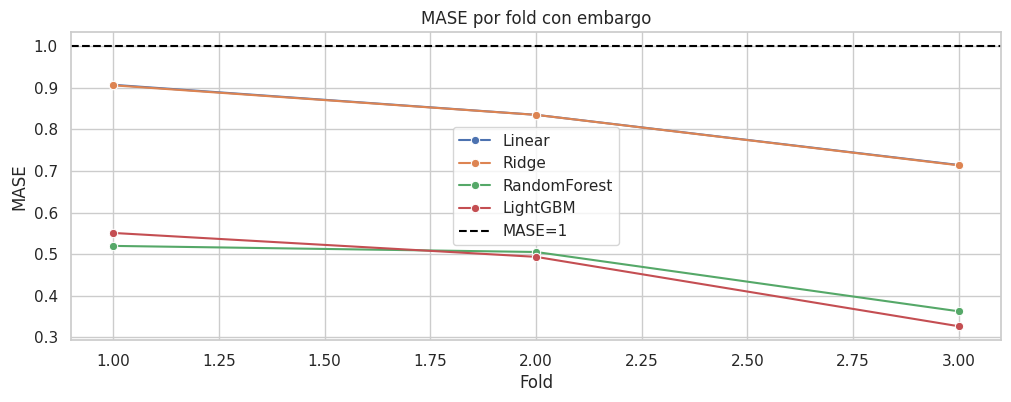

In [39]:
# MASE por fold: la línea MASE=1 es el naive semanal; por debajo, el modelo es útil.
fig,ax=plt.subplots(); sns.lineplot(data=scores,x="fold",y="MASE",hue="model",marker="o",ax=ax); ax.axhline(1,color="black",ls="--",label="MASE=1"); ax.set(title="MASE por fold con embargo",xlabel="Fold",ylabel="MASE"); ax.legend(); plt.show()

### 3.7 Forecast último fold

Zoom de siete días.

El gráfico superpone los forecasts de los cuatro modelos sobre el test final. Se busca un ajuste de nivel y de picos: los lineales suelen suavizar las puntas; los árboles siguen mejor la forma intradiaria. Inspección cualitativa; las métricas de 3.5 son la evidencia cuantitativa.

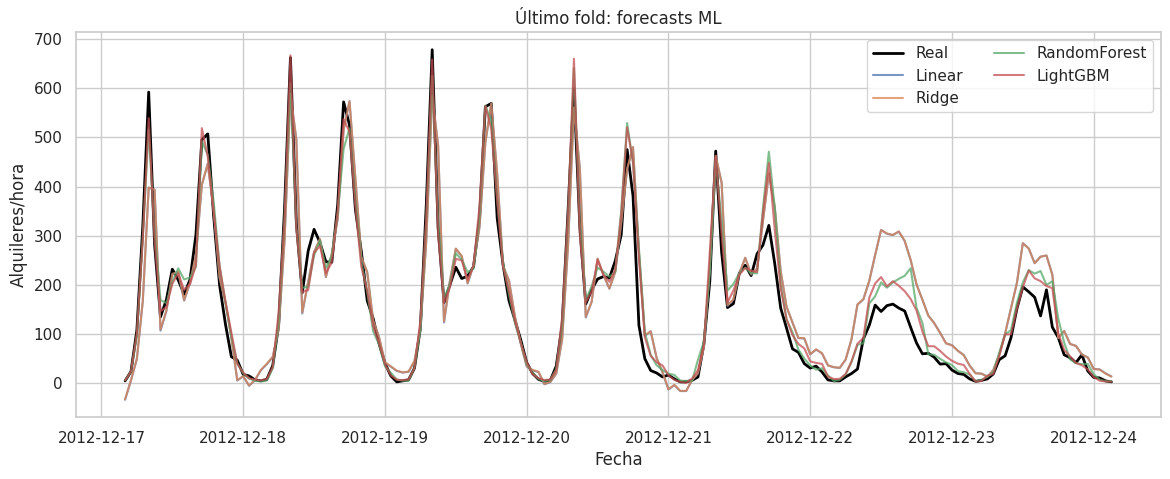

In [40]:
# Forecast del último fold (7 días): comparación visual de los cuatro modelos contra el real.
f=folds[-1]; te=model_df.iloc[f["test_start"]:f["test_end"]]; fig,ax=plt.subplots(figsize=(14,5)); ax.plot(te.index,te.cnt,color="black",label="Real",lw=2)
for name in build_models(): ax.plot(te.index,predictions[(3,name)],label=name,alpha=.75)
ax.set(title="Último fold: forecasts ML",xlabel="Fecha",ylabel="Alquileres/hora"); ax.legend(ncol=2); plt.show()

### 3.8 Importancia LightGBM

Gain/split importance nativa, descriptiva.

La importancia por splits cuenta cuántas veces cada feature se usa para partir los árboles del último fold. Es descriptiva y puede favorecer variables correlacionadas; por eso se complementa con permutation importance (3.9).

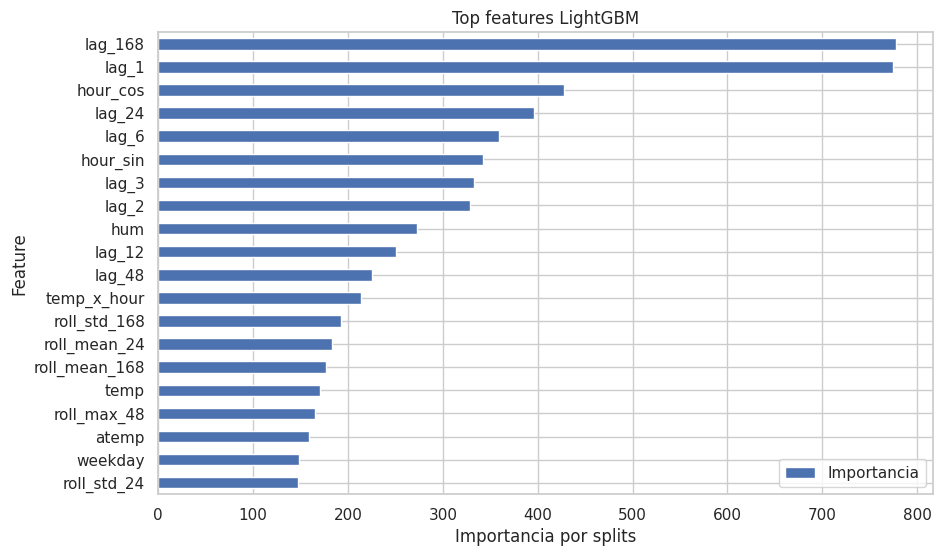

In [41]:
# Importancia por splits del LightGBM del último fold: frecuencia de uso de cada feature.
best_lgb=fitted[(3,"LightGBM")]; imp=pd.Series(best_lgb.feature_importances_,index=FEATURES).sort_values(ascending=False).head(20); fig,ax=plt.subplots(figsize=(10,6)); imp.sort_values().plot.barh(ax=ax,label="Importancia"); ax.set(title="Top features LightGBM",xlabel="Importancia por splits",ylabel="Feature"); ax.legend(); plt.show()

### 3.9 Permutation importance

Se calcula sobre el último test; caída en R² al permutar.

Se permutan las features del test y se mide cuánto empeora el error (MAE) del modelo ya entrenado. A diferencia de la importancia por splits, mide el efecto real sobre las predicciones del último fold, aunque depende de la correlación entre features y de ese test concreto.

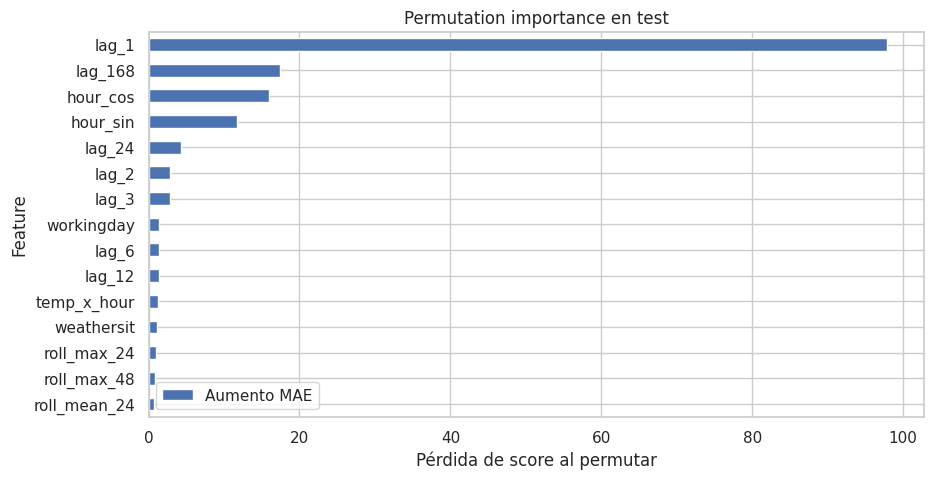

In [42]:
# Permutation importance sobre el test: caída de MAE al permutar cada feature (5 repeticiones).
perm=permutation_importance(best_lgb,te[FEATURES],te.cnt,n_repeats=5,random_state=SEED,n_jobs=-1,scoring="neg_mean_absolute_error"); pimp=pd.Series(perm.importances_mean,index=FEATURES).sort_values(ascending=False).head(15); fig,ax=plt.subplots(figsize=(10,5)); pimp.sort_values().plot.barh(ax=ax,label="Aumento MAE"); ax.set(title="Permutation importance en test",xlabel="Pérdida de score al permutar",ylabel="Feature"); ax.legend(); plt.show()

### 3.10 SHAP opcional

SHAP no es dependencia obligatoria. Si está instalado, el código puede activarse; permutation importance ya fue ejecutada.

La celda verifica disponibilidad sin instalar nada; en este entorno SHAP no está disponible y el notebook sigue siendo reproducible sin él. Para interpretar el modelo bastan la importancia por splits y la permutation importance; SHAP añadiría atribuciones por observación si el entorno lo permitiera.

In [43]:
# SHAP opcional: se detecta disponibilidad sin instalar; su ausencia no bloquea el notebook.
try:
    import shap
    shap_available=True
except Exception:
    shap_available=False
print("SHAP disponible:",shap_available,"; no es necesario para reproducir el notebook")

SHAP disponible: True ; no es necesario para reproducir el notebook


## 4. Análisis posterior (post-modeling)

Se analiza el mejor modelo por MASE medio, sin reoptimizar sobre test.

Una vez elegido LightGBM por su MASE medio en los tres folds, esta sección audita su comportamiento: residuos en el tiempo, autocorrelación, normalidad, heterocedasticidad y errores por segmento de negocio (pico/valle, festivos, estación, horizonte). El objetivo no es mejorar el modelo, sino saber **dónde y cuándo es fiable** antes de desplegarlo.

En términos de decisión: este análisis responde a la pregunta del operador de rebalanceo — "¿en qué horas y condiciones puedo confiar en el pronóstico para decidir, y cuándo debo usar juicio humano o reglas simples?" La fiabilidad segmentada es información operativa, no solo estadística.

### 4.1 Modelo seleccionado

Selección agregada en los tres folds.

La selección se hace sobre el resumen de los tres folds (media de MASE), nunca sobre un test concreto: elegir por el mejor resultado de un solo fold sería selección sobre test. Los residuos de los tres tests se concatenan para el análisis conjunto.

In [44]:
# Selección: mejor modelo por MASE medio agregado (LightGBM en los outputs).
# Se concatenan los residuos de los tres tests para el análisis posterior.
best_name=summary.index[0]; print("Mejor modelo:",best_name); residual_blocks=[]
for f in folds:
    te=model_df.iloc[f["test_start"]:f["test_end"]]; residual_blocks.append(pd.DataFrame({"residual":te.cnt-predictions[(f["fold"],best_name)],"fold":f["fold"]},index=te.index))
residual_df=pd.concat(residual_blocks)

Mejor modelo: LightGBM


### 4.2 Residuos temporales

Se revisan sesgo y estructura.

Si el modelo fuera correcto, los residuos oscilarían alrededor de cero sin patrón. El gráfico permite detectar sesgo (residuos sistemáticamente positivos o negativos) y rachas de error (periodos de fallo consecutivo), pistas de estructura no capturada.

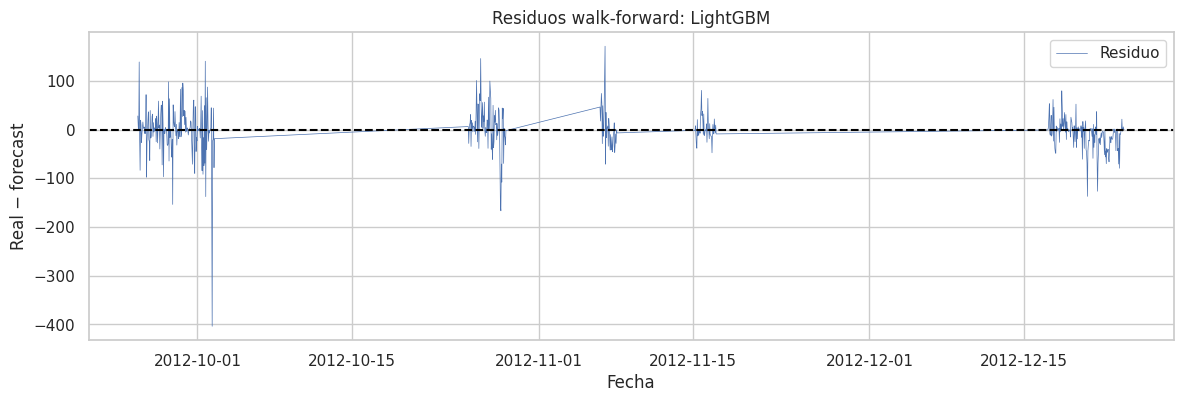

In [45]:
# Residuos walk-forward del mejor modelo: sesgo y estructura temporal.
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(residual_df.index,residual_df.residual,lw=.5,label="Residuo"); ax.axhline(0,color="black",ls="--"); ax.set(title=f"Residuos walk-forward: {best_name}",xlabel="Fecha",ylabel="Real − forecast"); ax.legend(); plt.show()

### 4.3 Ljung–Box

H₀: no autocorrelación hasta lag 24, por fold.

En los outputs, el fold 1 no rechaza (p ≈ 0.999), pero los folds 2 y 3 rechazan (p < 1e-11): quedan autocorrelaciones horarias sin capturar. Interpretación honesta: el modelo de referencia es útil, pero no agota la información temporal; queda margen para features o modelos más expresivos.

In [46]:
# Ljung-Box por fold con lag 24: autocorrelación remanente de los residuos.
rows=[]
for fold,g in residual_df.groupby("fold"):
    lb=acorr_ljungbox(g.residual,lags=[24],return_df=True).iloc[0]; rows.append({"fold":fold,"test":"Ljung-Box","H0":"sin autocorrelación","stat":lb.lb_stat,"p_value":lb.lb_pvalue,"decision":"rechazar H0" if lb.lb_pvalue<.05 else "no rechazar H0"})
pd.DataFrame(rows)

,fold,test,H0,stat,p_value,decision
0,1,Ljung-Box,sin autocorrelación,7.881358,9.991932e-01,no rechazar H0
1,2,Ljung-Box,sin autocorrelación,104.737279,4.623693e-12,rechazar H0
2,3,Ljung-Box,sin autocorrelación,166.739236,2.418428e-23,rechazar H0


### 4.4 Normalidad

Jarque–Bera H₀: normalidad.

Se rechaza la normalidad con claridad (skew −1.55, curtosis 18.2): residuos con colas pesadas y asimetría negativa, típicos de demanda con picos puntuales. Para un pronóstico puntual esto no invalida MAE/RMSE, pero advierte que los intervalos gaussianos serían incorrectos.

In [47]:
# Jarque-Bera sobre residuos agregados: normalidad rechazada (colas pesadas, skew negativo).
jb=jarque_bera(residual_df.residual); pd.DataFrame([{"test":"Jarque-Bera","H0":"normalidad","stat":jb[0],"p_value":jb[1],"decision":"rechazar H0" if jb[1]<.05 else "no rechazar H0","skew":jb[2],"kurtosis":jb[3]}])

,test,H0,stat,p_value,decision,skew,kurtosis
0,Jarque-Bera,normalidad,5079.392388,0.0,rechazar H0,-1.550373,18.240118


### 4.5 QQ-plot

Colas residuales.

El gráfico cuantil-cuantil confirma lo anunciado por Jarque–Bera: los extremos se desvían de la recta normal. Lectura operativa: los errores grandes son más frecuentes que en una normal y deben presupuestarse como colchón de bicicletas en el plan de flota.

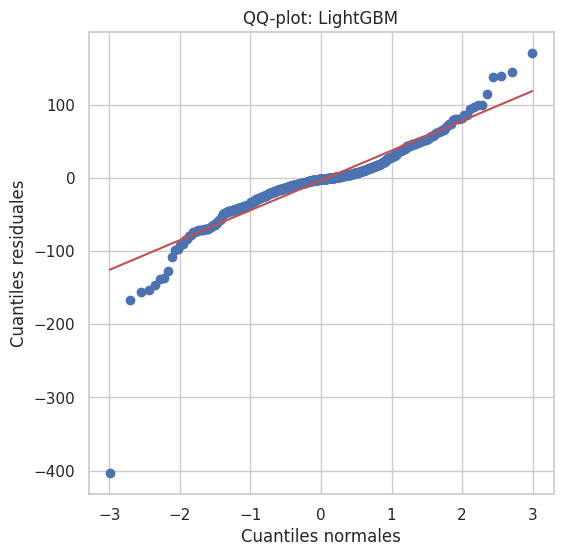

In [48]:
# QQ-plot: desviación de las colas respecto a la normal.
fig,ax=plt.subplots(figsize=(6,6)); stats.probplot(residual_df.residual,dist="norm",plot=ax); ax.set(title=f"QQ-plot: {best_name}",xlabel="Cuantiles normales",ylabel="Cuantiles residuales"); plt.show()

### 4.6 ARCH

H₀: homocedasticidad condicional.

El test ARCH sobre 24 lags no rechaza (p ≈ 0.40): no hay evidencia de que la varianza del error cambie de forma agrupada. En la práctica, la incertidumbre del forecast es relativamente estable, lo que simplifica el dimensionamiento del colchón operativo.

In [49]:
# ARCH LM con 24 lags: homocedasticidad condicional de los residuos.
a=het_arch(residual_df.residual,nlags=24); pd.DataFrame([{"test":"ARCH LM","H0":"homocedasticidad","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,ARCH LM,homocedasticidad,25.06571,0.402197,no rechazar H0


### 4.7 Hora pico vs valle

Pico se define 7–9 y 16–19.

La segmentación por horas punta es la más relevante para el negocio: en los outputs, el error absoluto medio en pico es 43.7 alquileres/hora frente a 20.9 en valle/resto. Las horas de máxima demanda son las más difíciles de pronosticar y las de mayor costo de error: ahí debe concentrarse el esfuerzo de mejora.

In [50]:
# Segmentación pico (7-9, 16-19) vs valle: error absoluto por segmento de negocio.
seg=[]
for f in folds:
    te=model_df.iloc[f["test_start"]:f["test_end"]]; err=(te.cnt-predictions[(f["fold"],best_name)]).abs(); peak=te.index.hour.isin([7,8,9,16,17,18,19]); seg.append(pd.DataFrame({"segment":np.where(peak,"pico","valle/resto"),"abs_error":err}))
pd.concat(seg).groupby("segment").abs_error.agg(["mean","median","count"])

,mean,median,count
segment,,,
pico,43.667748,35.455445,148
valle/resto,20.853412,11.688882,356


### 4.8 Festivo vs laboral

Segmentación solicitada.

En los tres tests no aparece ningún festivo (la tabla solo muestra "no festivo", 504 observaciones). Es un hallazgo de cobertura: el modelo no fue evaluado en días festivos, así que su comportamiento en esas fechas es una incertidumbre abierta, no una garantía.

In [51]:
# Segmentación festivo vs no festivo; la cobertura depende de los días presentes en los tests.
seg=[]
for f in folds:
    te=model_df.iloc[f["test_start"]:f["test_end"]]; err=(te.cnt-predictions[(f["fold"],best_name)]).abs(); seg.append(pd.DataFrame({"segment":np.where(te.holiday.eq(1),"festivo","no festivo"),"abs_error":err}))
pd.concat(seg).groupby("segment").abs_error.agg(["mean","median","count"])

,mean,median,count
segment,,,
no festivo,27.55286,16.393446,504


### 4.9 Estación

Error por season.

El test se concentra en otoño (season 4, 428 observaciones, MAE 28.3) y primavera (season 1, 76 observaciones, MAE 23.3). La cobertura estacional es desigual: los folds no cubren verano e invierno completos, limitación a considerar antes de extrapolar el MASE medio a todo el año.

In [52]:
# Error absoluto por estación (season 1-4) en los tests de los tres folds.
seg=[]
for f in folds:
    te=model_df.iloc[f["test_start"]:f["test_end"]]; err=(te.cnt-predictions[(f["fold"],best_name)]).abs(); seg.append(pd.DataFrame({"season":te.season,"abs_error":err}))
pd.concat(seg).groupby("season").abs_error.agg(["mean","median","count"])

,mean,median,count
season,,,
1.0,23.335140,14.137184,76
4.0,28.301801,16.545447,428


### 4.10 Error por horizonte

MAE dentro de 168 horas.

El error medio por horizonte revela cómo se degrada el forecast al alejarse del origen: los primeros horizontes suelen ser más precisos (los lags recientes ayudan) y la precisión se estabiliza o empeora después. Esta curva informa cuándo reentrenar y hasta qué horizonte tiene sentido comprometer la redistribución.

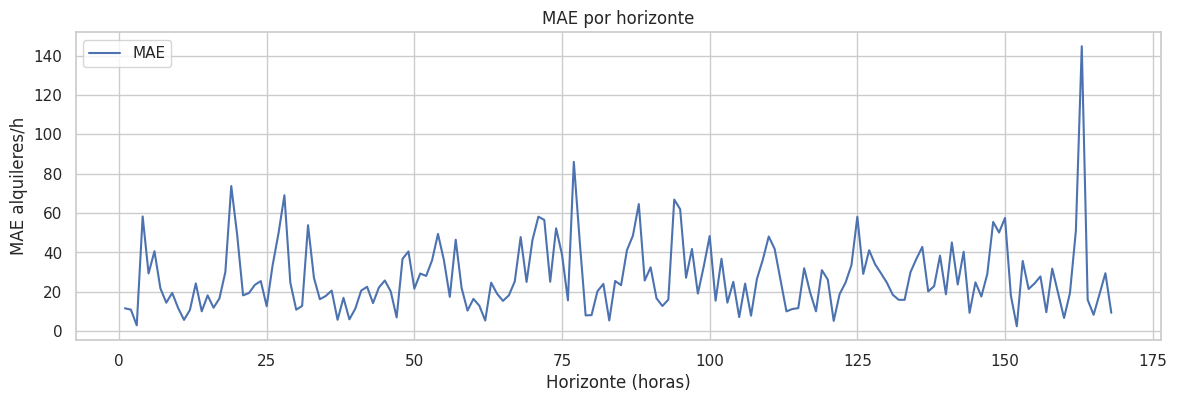

In [53]:
# MAE por horizonte (1..168 h): cómo se degrada el error con la distancia al origen.
h=[]
for f in folds:
    te=model_df.iloc[f["test_start"]:f["test_end"]]; err=(te.cnt-predictions[(f["fold"],best_name)]).abs().values
    for i,e in enumerate(err,1): h.append({"horizon":i,"abs_error":e})
h=pd.DataFrame(h).groupby("horizon").abs_error.mean(); fig,ax=plt.subplots(figsize=(14,4)); ax.plot(h.index,h,label="MAE"); ax.set(title="MAE por horizonte",xlabel="Horizonte (horas)",ylabel="MAE alquileres/h"); ax.legend(); plt.show()

### 4.11 Hour vs day

La agregación diaria suaviza picos y reduce tamaño, pero pierde patrones intradiarios.

La tabla de outputs resume el dilema de granularidad: el dataset horario tiene 17 379 filas y coeficiente de variación 0.957, frente a 731 filas y 0.430 en el diario. Menos filas y menos volatilidad facilitan el modelado agregado, pero un plan de redistribución horaria no puede construirse con un pronóstico diario.

In [54]:
# Comparación de granularidad: filas, coeficiente de variación y soporte intradiario.
comparison=pd.DataFrame({"dataset":["hour","day"],"rows":[len(hour_raw),len(day_raw)],"target_cv":[hour_raw.cnt.std()/hour_raw.cnt.mean(),day_raw.cnt.std()/day_raw.cnt.mean()],"supports_intraday":[True,False]}); comparison

,dataset,rows,target_cv,supports_intraday
0,hour,17379,0.957377,True
1,day,731,0.430076,False


### 4.12 Recomendación granularidad

Forecast operativo de disponibilidad de bicicletas requiere hora; planificación agregada puede usar día.

El gráfico final contrasta la riqueza intradiaria (dos semanas horarias) con la suavidad diaria (primer mes). **Decisión ejecutiva.** Para la operación de redistribución se adopta el modelo horario con: (1) lags desplazados y rolling sobre pasado con `shift(1)` como estándar de construcción de features; (2) embargo de 24 horas en toda evaluación; (3) LightGBM como modelo de referencia (mejor MASE medio, 0.457, en los outputs de la Sección 3). El modelo diario queda reservado para planificación agregada.

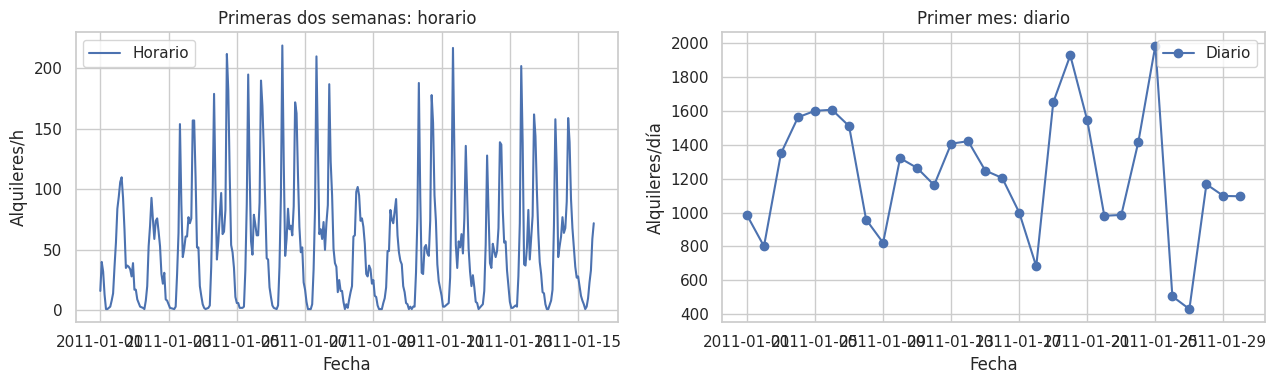

In [55]:
# Contraste visual: 2 semanas horarias vs 1 mes diario; la operación necesita la hora.
fig,axes=plt.subplots(1,2,figsize=(13,4)); axes[0].plot(hour_raw.ds.iloc[:24*14],hour_raw.cnt.iloc[:24*14],label="Horario"); axes[0].set(title="Primeras dos semanas: horario",xlabel="Fecha",ylabel="Alquileres/h"); axes[0].legend(); axes[1].plot(day_raw.dteday.iloc[:30],day_raw.cnt.iloc[:30],marker="o",label="Diario"); axes[1].set(title="Primer mes: diario",xlabel="Fecha",ylabel="Alquileres/día"); axes[1].legend(); plt.tight_layout(); plt.show()

## 5. Lecciones metodológicas

1. `shift(1)` antes de rolling es obligatorio.  
2. `casual` y `registered` reconstruyen exactamente el target y deben excluirse.  
3. El embargo de 24 horas separa el ciclo diario entre train y test.  
4. Importancia no implica causalidad; permutation importance depende del test y correlación entre features.  
5. La granularidad horaria sirve operación; la diaria, planificación agregada.  

**Conexión:** Semana 5 lleva el paradigma tabular a cientos de series con un modelo global.

**Checklist de reproducibilidad (Semana 4).** Para que cualquier persona — o un pipeline de CI — reproduzca este notebook: (a) fijar `seed=42` y los `random_state` de los modelos; (b) resolver rutas con `resolve()`; (c) verificar el contrato de datos con aserciones (dimensiones, identidad `cnt`, unicidad de `ds`); (d) construir features solo con pasado (`shift(1)` y embargo de 24 h); (e) excluir `casual`/`registered` de `X`; (f) usar modelos CPU con `n_jobs` acotado; (g) conservar los outputs de esta sesión.

> **Lo que este análisis NO puede afirmar:** que LightGBM es "el mejor modelo" en absoluto — es el mejor *en este dataset, con este protocolo, en estos tres folds*; que el feature engineering causal garantiza mejora — depende de que las features construidas capturen señal real, no solo correlación espuria; ni que el modelo se extrapola a otra ciudad, otro sistema de bicicletas u otro período sin validación local.

## 6. Ejercicios propuestos

1. **Fácil:** retire lag 168 y cuantifique la degradación.  
2. **Intermedio:** cambie embargo a 0, 12 y 48 horas.  
3. **Intermedio:** compare recursive vs direct multi-step.  
4. **Difícil:** implemente SHAP agrupando features correlacionadas.  
5. **Difícil:** genere intervalos conformales por hora del día.

**Pista anti-leakage para el ejercicio 2:** al reducir el embargo a 0, pregúntate si una eventual mejora de métricas refleja capacidad real de pronóstico o acceso a información futura.

In [56]:
# Cierre del notebook: resumen del mejor modelo y sus métricas medias entre folds.
print("Notebook 4 completado.")
print("Mejor modelo:",best_name)
print(summary.loc[best_name])

Notebook 4 completado.
Mejor modelo: LightGBM
MAE          mean     27.552860
             std       6.006900
RMSE         mean     42.836713
             std      11.553779
MASE         mean      0.457018
             std       0.116569
R2           mean      0.956830
             std       0.002218
fit_seconds  mean    110.952542
             std     188.473447
Name: LightGBM, dtype: float64
